텍스트 데이터 분류 문제를 대상으로:

데이터 전처리 (패딩, 원-핫 인코딩)

LSTM + CNN 모델 설계

학습 및 검증 손실/정확도 추적

복습용 실험 코드 (동일/변형 모델 재구현)

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.datasets import reuters       # 로이터 뉴스 데이터셋 불러오기
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눕니다.
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=1000, test_split=0.2)  # 빈도 순으로 상위 1,000개의 단어만 사용

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
category = np.max(y_train) + 1
print('카테고리: ', category)
print('학습용 뉴스 기사: ',len(X_train))
print('테스트용 뉴스 기사: ', len(X_test))
print(X_train[0])
print(X_train[1])

카테고리:  46
학습용 뉴스 기사:  8982
테스트용 뉴스 기사:  2246
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
[1, 2, 699, 2, 2, 56, 2, 2, 9, 56, 2, 2, 81, 5, 2, 57, 366, 737, 132, 20, 2, 7, 2, 49, 2, 2, 2, 2, 699, 2, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2, 2, 2, 775, 7, 48, 34, 191, 44, 35, 2, 505, 17, 12]


In [3]:
print(f"훈련 데이터 개수: {len(X_train)}")
print(f"테스트 데이터 개수: {len(X_test)}")
print(f"첫 번째 훈련 샘플: {X_train[0]}")
print(f"첫 번째 훈련 레이블: {y_train[0]}")

훈련 데이터 개수: 8982
테스트 데이터 개수: 2246
첫 번째 훈련 샘플: [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
첫 번째 훈련 레이블: 3


In [4]:
# 단어 수 맞추기
X_train = sequence.pad_sequences(X_train, maxlen=100)  # pad_sequences: 0을 앞에 붙임
X_test = sequence.pad_sequences(X_test, maxlen=100)
X_train[1]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   2, 699,   2,   2,  56,   2,   2,
         9,  56,   2,   2,  81,   5,   2,  57, 366, 737, 132,  20,   2,
         7,   2,  49,   2,   2,   2,   2, 699,   2,   8,   7,  10, 241,
        16, 855, 129, 231, 783,   5,   4, 587,   2,   2,   2, 775,   7,
        48,  34, 191,  44,  35,   2, 505,  17,  12], dtype=int32)

In [5]:
# 원-핫 인코딩 처리
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### **모델 1: 로이터 뉴스 분류 (LSTM 기반)**
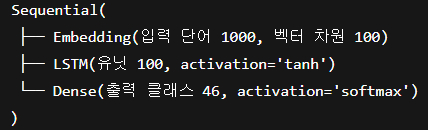


* 데이터셋: Reuters 뉴스 (46개 카테고리 분류)
* 손실 함수: categorical_crossentropy
* 옵티마이저: adam
* 콜백: EarlyStopping (val_loss 기준, patience=10)

In [6]:
# 모델 구조 설정
model = Sequential()
model.add(Embedding(1000, 100))
model.add(LSTM(100, activation='tanh'))
model.add(Dense(46, activation='softmax'))

# 모델의 실행 옵션 설정(딥러닝 모델을 훈련하기 전 마지막 단계로, 학습 방식과 평가 기준을 설정하는 함수)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# categorical_crossentropy: 다중 클래스 분류에 사용. 출력 레이어가 softmax이고, 정답 레이블이 원-핫 인코딩된 경우에 사용.
# 만약 레이블이 정수(예: 0, 1, 2, ...) 형태이고 원-핫 인코딩을 안 했다면, 'sparse_categorical_crossentropy' 用

# 학습의 조기 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # val_loss가 연속 5번 이상 좋아지지 않으면 멈추겠다.

# 모델 실행
history = model.fit(X_train, y_train, batch_size=20, epochs=200, validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.3862 - loss: 2.4260 - val_accuracy: 0.5183 - val_loss: 1.8785
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.5088 - loss: 1.9664 - val_accuracy: 0.5637 - val_loss: 1.7212
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.5752 - loss: 1.6507 - val_accuracy: 0.6215 - val_loss: 1.5275
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.6371 - loss: 1.4488 - val_accuracy: 0.6438 - val_loss: 1.4058
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 39s 81ms/step - accuracy: 0.6756 - loss: 1.2879 - val_accuracy: 0.6701 - val_loss: 1.3188
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.7163 - loss: 1.1037 - val_accuracy: 0.7026 - val_loss: 1.2073
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 39s 80ms/step - accuracy: 0.7536 - loss: 0.9932 - val_accuracy: 0.7168 - val_loss: 1.1615
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.7726 - loss: 0

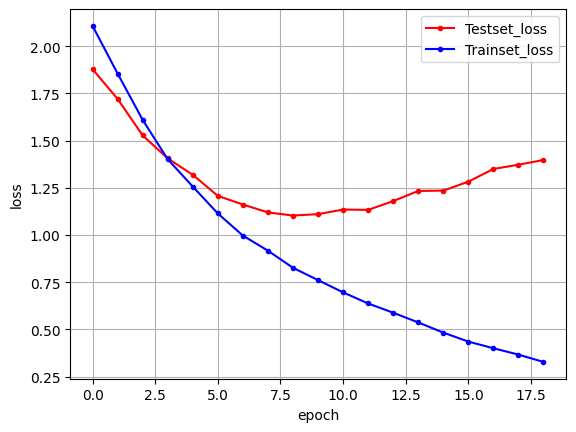

In [7]:
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

### **모델 2: 영화 리뷰 감성 분류 (CNN + LSTM)**
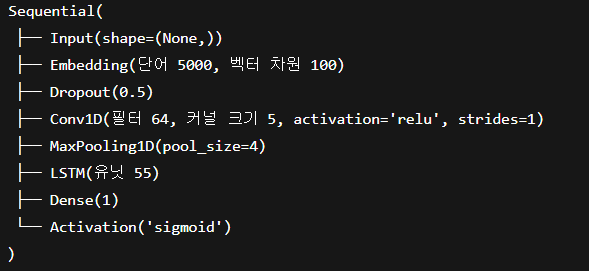

* 데이터셋: IMDB 영화 리뷰 (이진 분류: 긍정/부정)
* 손실 함수: binary_crossentropy (추정됨)
* 옵티마이저: adam
* 출력: sigmoid → 긍정/부정 확률

CNN + LSTM 구조는 텍스트의 의미와 흐름을 함께 고려하기 때문에 성능이 좋다.

In [8]:
    from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터 분할
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# 전처리(패딩)
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500)

# 모델 정의
model = Sequential([
    Input(shape=(None,)),
    Embedding(5000, 100),  # 단어 벡터화
    Dropout(0.5),
    Conv1D(64, 5, padding='valid', activation='relu', strides=1),  # n-gram 의미 추출
    MaxPooling1D(pool_size=4),  # 중요 정보만 추림
    LSTM(55),  # 순서 기반 문맥 학습
    Dense(1),
    Activation('sigmoid')  # 이진 분류 확률 추출
])
model.summary()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 100)      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 55)             │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,520 (2.13 MB)

 Trainable params: 558,520 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

**CNN 뒤에 LSTM을 둔 이유**

Conv1D를 먼저 두는 이유는 문장 속 국소 패턴(n-그램)을 빠르게 추출하고(예: 부정 표현, 강한 형용사 등), MaxPooling으로 시간 축을 압축해 노이즈를 줄이고 연산량을 크게 낮춘 뒤 그 순차적 특징열을 LSTM에 넘겨 장기 의존성과 순서 정보를 학습하게 하려는 설계이기 때문입니다. 이렇게 하면 LSTM이 처음부터 긴 시퀀스 전체를 처리하지 않아도 되어 학습이 더 안정적이고 빠르며, CNN이 잡은 특징적인 의미와 LSTM이 학습한 전역 문맥을 결합해 성능과 효율을 동시에 얻을 수 있습니다.

In [9]:
# 모델의 실행 옵션 설정
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습의 조기 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델 실행
history = model.fit(X_train, y_train, batch_size=40, epochs=100, validation_split=0.25, callbacks=[early_stopping_callback])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 224ms/step - accuracy: 0.6841 - loss: 0.5577 - val_accuracy: 0.8819 - val_loss: 0.2929
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 220ms/step - accuracy: 0.9053 - loss: 0.2453 - val_accuracy: 0.8856 - val_loss: 0.2832
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 220ms/step - accuracy: 0.9338 - loss: 0.1822 - val_accuracy: 0.8896 - val_loss: 0.2681
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 221ms/step - accuracy: 0.9515 - loss: 0.1401 - val_accuracy: 0.8824 - val_loss: 0.2982
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 216ms/step - accuracy: 0.9621 - loss: 0.1168 - val_accuracy: 0.8880 - val_loss: 0.2940
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - accuracy: 0.9700 - loss: 0.0870 - val_accuracy: 0.8885 - val_loss: 0.3398
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 219ms/step - accuracy: 0.9790 - loss: 0.0682 - val_accuracy: 0.8821 - val_loss: 0.3743
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 221ms/step - accuracy: 

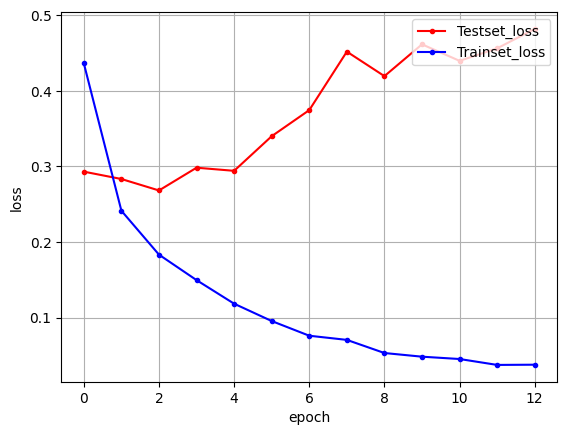

In [10]:
# 학습셋과 테스트셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 보겠습니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()



---



첫 번째 모델은 순수 LSTM으로 뉴스 분류 (다중 클래스).

두 번째 모델은 CNN + LSTM 결합 구조로 영화 리뷰 감정 분류 (이진 분류).



---



```
model = Sequential()
model.add(Embedding(1000, 100))
model.add(LSTM(100, activation='tanh'))
model.add(Dense(46, activation='softmax'))
```

1️⃣ Embedding(1000, 100)

✅ 역할: 단어를 벡터로 변환 (임베딩)

입력: 정수로 인코딩된 단어 시퀀스 (예: [23, 54, 2, 999])

작동 방식: 각 단어 인덱스를 길이 100짜리 벡터로 변환

1000: 사용할 단어 수 (단어 집합 크기)

100: 각 단어를 100차원 벡터로 변환

예:
23 → [0.1, -0.3, ..., 0.7] (길이 100 벡터)

이 층은 자연어 처리에서 필수적으로 사용하는 층이에요.

2️⃣ LSTM(100, activation='tanh')

✅ 역할: 시퀀스(문장)를 순서대로 읽으며 의미 파악

LSTM: Long Short-Term Memory, 순환 신경망(RNN)의 일종

입력: 단어 임베딩 벡터의 시퀀스

100: LSTM 셀의 개수 → 출력도 100차원 벡터

activation='tanh': 셀 내부 연산에 쓰이는 비선형 함수

LSTM은 문맥을 기억하고, 시퀀스 정보를 잘 반영하기 때문에 텍스트 분류에 매우 효과적입니다.

3️⃣ Dense(46, activation='softmax')

✅ 역할: 마지막 분류기 (출력층)

Dense(46): 출력 뉴런 수 46개 → 로이터 데이터셋에는 46개의 뉴스 카테고리가 있기 때문

activation='softmax': 확률 분포를 만들기 위한 함수
→ 예측 결과가 [0.02, 0.01, ..., 0.85, ..., 0.01]처럼 총합 1인 확률 벡터로 나옴

즉, 이 층은 뉴스가 어떤 카테고리에 속할 확률을 출력합니다.



---





```
loss='categorical_crossentropy'
```
이 함수는 예측 확률과 실제 정답 벡터 간의 차이를 계산하여, 그 오차를 줄이도록 학습하게 합니다.

예:

실제 정답 → [0, 1, 0, 0, ..., 0]

모델 예측 → [0.1, 0.7, 0.1, 0.05, ..., 0.01]

→ 두 벡터의 차이를 계산하여 loss를 구합니다.



---



```
optimizer='adam'
```

옵티마이저: 손실(loss)을 최소화하기 위해 가중치를 어떻게 업데이트할지 결정하는 알고리즘

adam: 현재 가장 많이 쓰이는 옵티마이저 중 하나

장점:

학습 속도 빠름

튜닝 필요 거의 없음

SGD보다 안정적



---



### **CNN+LSTM**

```
model = Sequential([
    Input(shape=(None,)),
    Embedding(5000, 100),  
    Dropout(0.5),
    Conv1D(64, 5, padding='valid', activation='relu', strides=1),
    MaxPooling1D(pool_size=4),
    LSTM(55),
    Dense(1),
    Activation('sigmoid')
])
```

```
Input(shape=(None,))
```
: 입력 시퀀스 길이는 가변적임을 의미 (None).

예: [4, 150, 320, 1, 88, ...] 같은 정수 인코딩된 문장을 입력으로 받을 수 있다.

```
Embedding(5000, 100)
```
: 단어 인덱스(정수)를 벡터로 변환

5000: 사용하는 단어 수

100: 각 단어를 100차원으로 임베딩

```
Conv1D(64, 5, padding='valid', activation='relu', strides=1)
```
: 1D 합성곱(CNN)을 사용하여 문장 내 지역적인 패턴(예: "not good", "very bad")을 감지

- 64: 필터 개수 → 출력 채널 수
- 5: 필터(커널) 크기 → 단어 5개씩 묶어서 패턴 탐색
- padding='valid': 패딩 없이 계산 → 출력 길이가 줄어듦
- activation='relu': 활성화 함수로 비선형성 부여

🧠 CNN은 국소적인 의미 조각들(n-gram)을 효과적으로 추출한다.

```
MaxPooling1D(pool_size=4)
```

: 합성곱 결과 중 가장 중요한 특징만 추출 (다운샘플링)
- pool_size=4: 4칸씩 묶어서 가장 큰 값만 선택 → 특징 크기를 줄이고, 연산량도 감소시킴

```
LSTM(55)
```

: CNN으로 추출된 특징 시퀀스를 시간 순서대로 이해
- 55: LSTM 유닛 수 → 출력 벡터는 55차원

🧠 CNN이 "무엇이 있는지"를 찾았다면,
LSTM은 "그게 어떤 순서로 나오는지"를 기억해줍니다.

```
Dense(1)
```
: 마지막 출력층
- 노드 1개 → 이진 분류를 위한 확률 출력용

```
Activation('sigmoid')
```
: 출력값을 0~1 사이 확률로 바꿈
- 0에 가까우면 클래스 0, 1에 가까우면 클래스 1로 예측



---



 #